# Reinforcement Learning Lab: Q-Learning Implementation and Testing

## Delivery Rider Example: Home → Street → Shop → Customer

In this lab, we will implement **Q-Learning** step by step using a simple delivery rider example.

The rider starts from **Home** and must reach the **Customer** by passing through **Street** and **Shop**.

### Main idea
The rider learns the best path by trying actions again and again. After training, the rider should learn this path:

**Home → Street → Shop → Customer**

## Step 1: Import Required Libraries

We need two libraries:

- `numpy` for creating and updating the Q-table
- `random` for choosing random actions during exploration

In [1]:
import numpy as np
import random

## Step 2: Define the Environment States

A **state** means the current location of the rider.

In our example, we have four states:

| State Number | Location |
|---|---|
| 0 | Home |
| 1 | Street |
| 2 | Shop |
| 3 | Customer |

The goal is to reach the **Customer**.

In [2]:
states = ["Home", "Street", "Shop", "Customer"]
n_states = len(states)

print("States:")
for i, state in enumerate(states):
    print(i, "=", state)

States:
0 = Home
1 = Street
2 = Shop
3 = Customer


## Step 3: Define the Actions

An **action** means what the rider can do.

The rider has two actions:

| Action Number | Action |
|---|---|
| 0 | Go Back |
| 1 | Go Forward |

Example:

If the rider is at **Home** and chooses **Go Forward**, the rider moves to **Street**.

In [3]:
actions = ["Go Back", "Go Forward"]
n_actions = len(actions)

print("Actions:")
for i, action in enumerate(actions):
    print(i, "=", action)

Actions:
0 = Go Back
1 = Go Forward


## Step 4: Create the Q-Table

The **Q-table** stores the learning of the rider.

Rows represent states, and columns represent actions.

At the start, the rider knows nothing, so all values are zero.

In [4]:
Q = np.zeros((n_states, n_actions))

print("Initial Q-table:")
print(Q)

Initial Q-table:
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


## Step 5: Define Learning Parameters

These parameters control how the rider learns.

| Parameter | Meaning |
|---|---|
| `alpha` | Learning rate: how fast the rider updates learning |
| `gamma` | Discount factor: how important future reward is |
| `epsilon` | Exploration rate: how often the rider tries random actions |
| `episodes` | Number of practice rounds |

A higher number of episodes means the rider gets more practice.

In [5]:
alpha = 0.1       # learning rate
gamma = 0.9       # discount factor
epsilon = 0.2     # exploration rate
episodes = 300    # training rounds

print("alpha =", alpha)
print("gamma =", gamma)
print("epsilon =", epsilon)
print("episodes =", episodes)

alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 300


## Step 6: Create the Environment Step Function

This function tells us what happens when the rider takes an action.

Rules:

- If action is **Go Forward**, the rider moves one step forward
- If action is **Go Back**, the rider moves one step backward
- The rider cannot move before Home
- The rider cannot move after Customer

Reward system:

| Situation | Reward |
|---|---|
| Reaches Customer | +20 |
| Moves forward but not customer | -1 |
| Moves backward | -2 |

This reward system teaches the rider to reach the customer quickly and avoid going backward.

In [7]:
def step(state, action):
    """
    This function receives current state and selected action.
    It returns next_state and reward.
    """

    # Action 1 means Go Forward
    if action == 1:
        next_state = min(state + 1, n_states - 1)  #tries to stop on cusomter by using min logic here

    # Action 0 means Go Back
    else:
        next_state = max(state - 1, 0)  #tries to not go back from even home by using max logic

    # Reward logic
    if next_state == n_states - 1:
        reward = 20
    elif action == 0:
        reward = -2
    else:
        reward = -1

    return next_state, reward

## Step 7: Test the Step Function

Before training, we test the environment manually.

Example:

Current state = Home  
Action = Go Forward  
Expected next state = Street

In [8]:
current_state = 0      # Home
selected_action = 1    # Go Forward

next_state, reward = step(current_state, selected_action)

print("Current State:", states[current_state])
print("Action:", actions[selected_action])
print("Next State:", states[next_state])
print("Reward:", reward)

Current State: Home
Action: Go Forward
Next State: Street
Reward: -1


## Step 8: Understand the Q-Learning Formula

The Q-learning formula updates the Q-table.

```text
New Q-value = Old Q-value + alpha × (reward + gamma × best future Q-value - Old Q-value)
```

Meaning:

- The rider checks the old value
- The rider receives reward
- The rider looks at the best possible future value
- Then the rider updates the Q-table

## Step 9: Train the Rider Using Q-Learning

In training:

1. The rider starts from Home
2. The rider chooses an action
3. The rider moves to the next location
4. The rider receives reward
5. The Q-table is updated
6. This repeats until the rider reaches the Customer

The rider does this many times, so learning improves.

In [9]:
# Reset Q-table before training
Q = np.zeros((n_states, n_actions))

# Store rewards for analysis
episode_rewards = []

for episode in range(episodes):
    state = 0  # rider starts from Home
    total_reward = 0

    while state != n_states - 1:  # continue until Customer

        # Epsilon-greedy action selection
        # Sometimes explore randomly, otherwise choose best known action
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, n_actions - 1)
        else:
            action = np.argmax(Q[state])

        # Take action in environment
        next_state, reward = step(state, action)

        # Old Q-value
        old_value = Q[state, action]

        # Best future Q-value from next state
        best_future_value = np.max(Q[next_state])

        # Q-learning update formula
        new_value = old_value + alpha * (reward + gamma * best_future_value - old_value)

        # Update Q-table
        Q[state, action] = new_value

        # Move to next state
        state = next_state

        # Add reward
        total_reward += reward

    episode_rewards.append(total_reward)

print("Training completed!")

Training completed!


## Step 10: Display the Learned Q-Table

After training, the Q-table contains learned values.

Higher value means better action.

For example, if **Go Forward** has a higher value than **Go Back**, the rider learned that moving forward is better.

In [10]:
print("Learned Q-table:")

for i, state_name in enumerate(states):
    print(state_name, "=>", Q[i])

Learned Q-table:
Home => [10.59004431 14.3       ]
Street => [10.4206102 17.       ]
Shop => [12.54031246 20.        ]
Customer => [0. 0.]


## Step 11: Convert Q-Table into a Policy

A **policy** tells the rider which action to take in each state.

We choose the action with the highest Q-value.

In [11]:
print("Learned Policy:")

for i, state_name in enumerate(states):
    best_action = np.argmax(Q[i])
    print(state_name, "=>", actions[best_action])

Learned Policy:
Home => Go Forward
Street => Go Forward
Shop => Go Forward
Customer => Go Back


# Testing Section

Now we test the trained rider.

During testing, the rider does not explore randomly.  
The rider only follows the best learned action from the Q-table.

## Step 12: Test the Trained Rider

The rider starts from Home.

At each state, the rider chooses the best action from the learned Q-table.

Expected final path:

**Home → Street → Shop → Customer**

In [12]:
state = 0
path = [states[state]]
total_test_reward = 0

while state != n_states - 1:
    action = np.argmax(Q[state])
    next_state, reward = step(state, action)

    print("State:", states[state], "| Action:", actions[action], "| Next State:", states[next_state], "| Reward:", reward)

    state = next_state
    path.append(states[state])
    total_test_reward += reward

print("Final Path:")
print(" -> ".join(path))
print("Total Test Reward:", total_test_reward)

State: Home | Action: Go Forward | Next State: Street | Reward: -1
State: Street | Action: Go Forward | Next State: Shop | Reward: -1
State: Shop | Action: Go Forward | Next State: Customer | Reward: 20
Final Path:
Home -> Street -> Shop -> Customer
Total Test Reward: 18


## Step 13: Plot Training Rewards

This plot shows how rewards changed during training.

In the beginning, the rider may make mistakes.  
After training, the rider should receive better rewards.

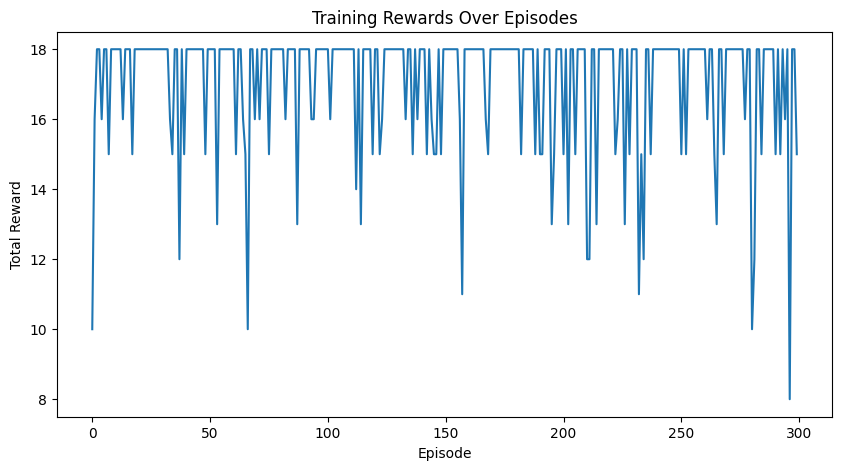

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Rewards Over Episodes")
plt.show()

## Step 14: Try Your Own Experiments

Change these values and run the notebook again:

```python
epsilon = 0.0
```

This means no exploration.

```python
epsilon = 1.0
```

This means full random exploration.

Observe how the Q-table and final path change.

# Final Summary

## Q-Function

A Q-function tells us how good an action is in a state.

Example:

```text
Q(Home, Go Forward)
```

means:

```text
How good is it to go forward from Home?
```

## Q-Learning

Q-learning is the algorithm that learns these Q-values through practice.

The rider starts with no knowledge.  
After many episodes, the rider learns the best route:

**Home → Street → Shop → Customer**